# FACTOID Corpus Exploration
Exploración rápida del dataset procesado a nivel usuario (`reddit_users_text_label.csv`).

> Objetivo: entender volumen, etiquetas, calidad del texto y ejemplos representativos antes de modelar.

In [6]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Ensure src/ is importable from either project root or notebooks/ cwd
project_root = Path.cwd()
if not (project_root / "src").exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "src"))

from political_bias_api.core.paths import USERS_CSV

df = pd.read_csv(USERS_CSV)
print(f"Loaded: {USERS_CSV}")
print(f"Rows: {len(df):,} | Columns: {len(df.columns)}")
df.head(3)

Loaded: /Users/sandrasanchezp/projects/nlp-political-bias-api/data/processed/reddit_users_text_label.csv
Rows: 4,150 | Columns: 4


,user_id,label,n_posts,text
0,ddf62a134f09db7a6056190d594bd41ff2f4cf04faf5db...,0,317,The fact that this has to be explained is what...
1,a78d753b103a2a4310ad6d1d49723733a6e4744bbf1beb...,0,392,Shelby County vs Holder. One of the worst and ...
2,19a734ee97b484a1a6c9625a1a3a0b5ddbabde3679ee2c...,0,3266,I've heard audio of him saying he'd fuck his d...


In [7]:
# 1) Dataset structure and basic health checks
display(df.dtypes.to_frame("dtype"))

missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
display(missing_pct.to_frame("missing_%").head(10))

print("\nQuick checks")
print("- unique users:", df["user_id"].nunique())
print("- duplicated users:", int(df["user_id"].duplicated().sum()))
print("- empty text rows:", int(df["text"].fillna("").str.strip().eq("").sum()))

,dtype
user_id,object
label,int64
n_posts,int64
text,object


,missing_%
user_id,0.0
label,0.0
n_posts,0.0
text,0.0



Quick checks
- unique users: 4150
- duplicated users: 0
- empty text rows: 0


,count,percent
label,,
0,3064,73.83
1,1086,26.17


/var/folders/69/_plt7pmj5hj1scqbf0lqwmsm0000gn/T/ipykernel_43157/4285764177.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x="label", order=sorted(df["label"].unique()), palette="Set2")


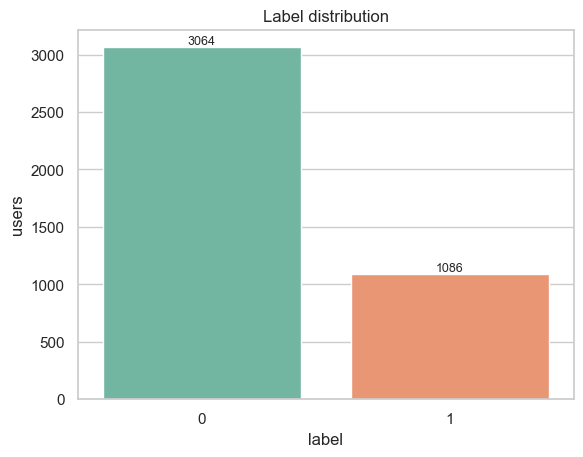

In [ ]:
# 2) Label distribution
label_counts = df["label"].value_counts().sort_index()
label_pct = (df["label"].value_counts(normalize=True).sort_index() * 100).round(2)

summary = pd.DataFrame({
    "count": label_counts,
    "percent": label_pct,
})
display(summary)

ax = sns.countplot(
    data=df,
    x="label",
    hue="label",
    order=sorted(df["label"].unique()),
    palette="Set2",
    legend=False,
    dodge=False,
    linewidth=0,
    edgecolor=None,
 )
ax.set_title("Label distribution")
ax.set_xlabel("label")
ax.set_ylabel("users")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontsize=9)
plt.show()

,n_posts
count,4150.000000
mean,808.299036
std,980.007318
min,11.000000
50%,488.000000
75%,967.000000
90%,1826.200000
95%,2655.000000
99%,5294.060000
max,9562.000000


/var/folders/69/_plt7pmj5hj1scqbf0lqwmsm0000gn/T/ipykernel_43157/3073390108.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df, x="label", y="n_posts", palette="Set3")


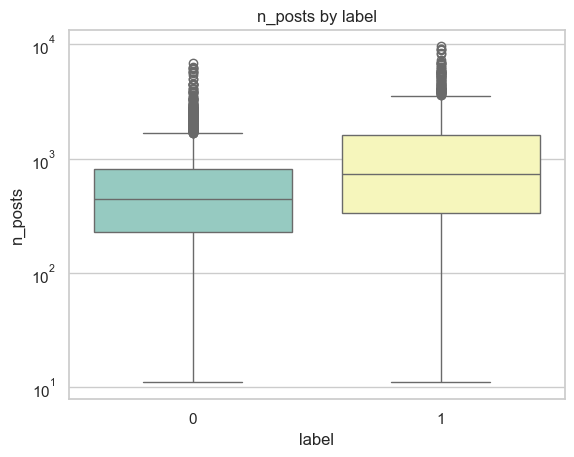

In [ ]:
# 3) Posts-per-user behaviour
posts_desc = df["n_posts"].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]).to_frame("n_posts")
display(posts_desc)

ax = sns.boxplot(
    data=df,
    x="label",
    y="n_posts",
    hue="label",
    palette="Set3",
    legend=False,
    dodge=False,
 )
ax.set_title("n_posts by label")
ax.set_xlabel("label")
ax.set_ylabel("n_posts")
plt.yscale("log")
plt.show()

,count,mean,std,min,50%,75%,90%,95%,99%,max
text_len_chars,4150.0,185955.112771,268560.132784,873.0,104375.5,209449.5,421597.4,614211.75,1349269.68,4711537.0
text_len_words,4150.0,30355.874217,42246.595344,154.0,17189.0,34942.0,68886.6,99774.55,213699.19,611566.0


/var/folders/69/_plt7pmj5hj1scqbf0lqwmsm0000gn/T/ipykernel_43157/4096423221.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="label", y="text_len_words", ax=axes[1], palette="Set2")


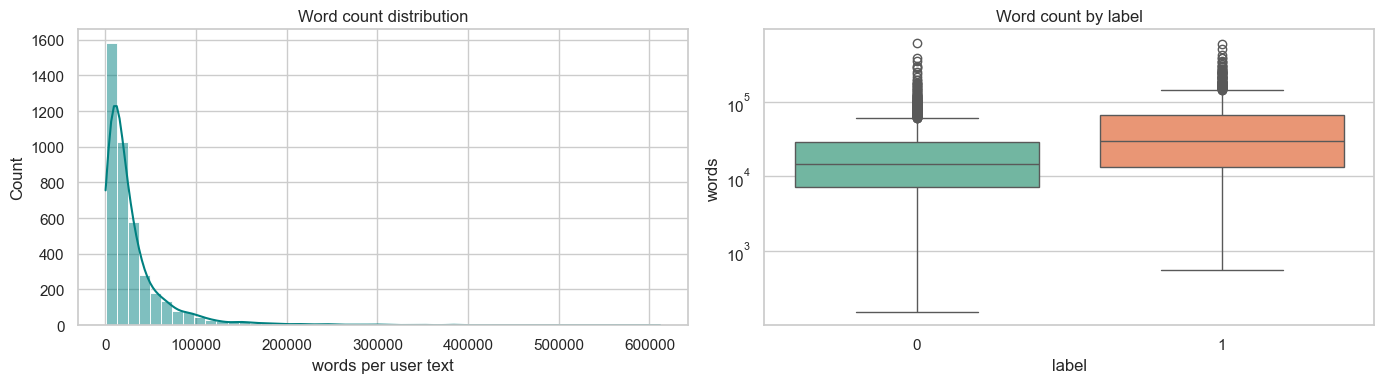

In [ ]:
# 4) Text length analysis
df["text_len_chars"] = df["text"].fillna("").str.len()
df["text_len_words"] = df["text"].fillna("").str.split().str.len()

display(
    df[["text_len_chars", "text_len_words"]]
    .describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])
    .T
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df["text_len_words"], bins=50, kde=True, ax=axes[0], color="teal")
axes[0].set_title("Word count distribution")
axes[0].set_xlabel("words per user text")

sns.boxplot(
    data=df,
    x="label",
    y="text_len_words",
    hue="label",
    ax=axes[1],
    palette="Set2",
    legend=False,
    dodge=False,
 )
axes[1].set_title("Word count by label")
axes[1].set_xlabel("label")
axes[1].set_ylabel("words")
axes[1].set_yscale("log")
plt.tight_layout()
plt.show()

In [11]:
# 5) Qualitative examples (sample texts by label)
pd.set_option("display.max_colwidth", 180)

for target_label in sorted(df["label"].unique()):
    print(f"\n=== label {target_label} ===")
    sample = (
        df[df["label"] == target_label]
        [["user_id", "n_posts", "text_len_words", "text"]]
        .sample(3, random_state=42)
        .reset_index(drop=True)
    )
    display(sample)


=== label 0 ===


,user_id,n_posts,text_len_words,text
0,61e3ab21ea343fbc9fa62a7d6dc30b8da95012c9902d67c0660f576b7d591ddb,1063,58718,"That's what I wish a lot of people realized. When the Democratic senate refused to, say, confirm Bork for Reagan, it wasn't a debate if Reagan got to fill the seat. It was a ..."
1,c79ffcab2b800ba115d9d9303cfd7baa63bc4e769f4e11bd38478ce66342e7b0,1548,29905,"Yeah, they don't care about people. They care about clutching their pearls.\nJoe Biden Leads President Donald Trump In Pennsylvania In 2020 Election, Poll Shows\nBiden's origin..."
2,abf1b46a29cf0999422b71a380fc5c36773ac299a35de9293b439050bd7e9231,316,17242,It's almost like the entire Trump admin is an organized crime enterprise.\nAnyone find it absolutely bizarre that Trump supporters are so heavily invested in HCQ? It's like th...



=== label 1 ===


,user_id,n_posts,text_len_words,text
0,e7016d6b05c553babf99fa4223716ba60b13d29712690ae1c10fa93cd963f86e,168,11981,&gt; He'll appoint judges that are 2a friendly. He has appointed judges that are recommended to him by the Federalist Society. We do not know how they will vote on 2A issues...
1,acc686561041edb48452ac5068e89c4644f09809f3a6560e2028ba7f201ed8a5,1699,57600,Should a woman be allowed to take drugs to intentionally give the child birth defects?\nWho is being wronged if there is no person? The person simply comes into being with the ...
2,c73c73d779061cdd506dec42e2138a61cfcac883f0ef65eec3ccfdd87c8c7638,1253,61187,"&gt; this is bigger than Trump and there is something that is keeping these asshats in line. The leaking of hacked democrat emails was widely publicized. However, [Russian hac..."


In [12]:
# 6) What exactly is in processed CSV? (raw vs processed)
from political_bias_api.core.paths import CORPUS_PKL

raw_df = pd.read_pickle(CORPUS_PKL)

def is_valid_doc(doc):
    return isinstance(doc, (list, tuple)) and len(doc) >= 2 and str(doc[1]).strip() != ""

raw_total_docs = int(raw_df["documents"].apply(lambda docs: len(docs) if isinstance(docs, list) else 0).sum())
raw_valid_docs = int(raw_df["documents"].apply(
    lambda docs: sum(1 for d in docs if is_valid_doc(d)) if isinstance(docs, list) else 0
).sum())

print("RAW users:", len(raw_df))
print("Processed rows (users):", len(df))
print("One row per user in processed:", len(df) == df["user_id"].nunique())
print("Same user count raw vs processed:", len(raw_df) == len(df))

print("\nDocs coverage")
print("- Raw total docs in documents lists:", raw_total_docs)
print("- Raw valid docs used by prepare script:", raw_valid_docs)
print("- Processed represented docs (sum n_posts):", int(df["n_posts"].sum()))
print("- Valid docs == sum(n_posts):", raw_valid_docs == int(df["n_posts"].sum()))

print("\nColumns kept in processed:", list(df.columns))
print("Columns dropped from raw (example count):", len(raw_df.columns) - len(df.columns))

RAW users: 4150
Processed rows (users): 4150
One row per user in processed: True
Same user count raw vs processed: True

Docs coverage
- Raw total docs in documents lists: 3354450
- Raw valid docs used by prepare script: 3354441
- Processed represented docs (sum n_posts): 3354441
- Valid docs == sum(n_posts): True

Columns kept in processed: ['user_id', 'label', 'n_posts', 'text', 'text_len_chars', 'text_len_words']
Columns dropped from raw (example count): 4160


In [13]:
# 7) Can I see all rows? Yes (but better inspect in chunks)

# Fast and safe views
display(df.head(10))
display(df.tail(10))
display(df.sample(10, random_state=7))

# If you REALLY want all rows in notebook output (can be heavy):
# pd.set_option("display.max_rows", None)
# display(df)

# Recommended for full inspection outside notebook UI:
# df.to_csv("/tmp/reddit_users_text_label_all_rows.csv", index=False)

,user_id,label,n_posts,text,text_len_chars,text_len_words
0,ddf62a134f09db7a6056190d594bd41ff2f4cf04faf5db32406bbec473f46935,0,317,The fact that this has to be explained is what's crazy. We have a whole generation of Americans who started paying attention to politics in the last 5 years who... do not have ...,270393,44385
1,a78d753b103a2a4310ad6d1d49723733a6e4744bbf1beb4d0e484a48fcf73870,0,392,"Shelby County vs Holder. One of the worst and most important SCOTUS decision in the recent past.\nYeah, he's gonna be known for Citizens United and Shelby whether he likes it o...",75034,12575
2,19a734ee97b484a1a6c9625a1a3a0b5ddbabde3679ee2c8e25e85dc6017bff59,0,3266,"I've heard audio of him saying he'd fuck his daughter.\nand lots of women hosts, incase people think it was some boys talk or some other weird masculine thing.\nyes. Trump woul...",520889,84619
3,d57699be1824c59714fb9a799b7b5b670227b07e2bde0064536151f6cf8fd9fd,0,626,"No. The democrats and with as many Republicans that will join need to thumb down on what this piece of s$hit has done in office. Anyone coming after him, whether that is Biden,...",131730,21482
4,26d0132074c91843483fb0f8b0378083f876d748be172b7f8982511d36771efe,1,142,"So, two weeks at Club Fed and 5 lashings with a wet noodle?\nThe silence by the right-wing-2A bootlickers that puff about states rights, claiming to be against the overstepping...",61853,8859
5,9905cf47617f7c6a4c38ffa57f5bae048b94fec61a339ce3e07bdbd53db74352,0,237,If we can't elect people willing to ban lobbyists and reverse corporate personhood we're fairly well screwed.\nDonald Trump Jr baselessly accused Joe Biden of being a 'pedophil...,24678,3912
6,096846064c66c7a73d5cc7a7341d2ffa637d2e86e21b145df470017b0d4ceec0,0,544,"&gt; Three weeks ago, the prison had reported only three confirmed cases of the virus\n&gt; The 14th Amendment's text plainly states that ""no person shall ... hold any office, ...",128668,19307
7,67ffb77c37ab42f6c413c96155838369325075d672f2e687fb5bd1f07010c2ca,0,328,"I appreciate all the work Woodward has done over the decades, including this, to keep the American public informed. His reporting has been vital. I also understand the need for...",131769,22624
8,ddd77aebb4eb4cac21edc339e54c6618493a0cf64310c8faa9df0c178b0161ea,1,903,Pics? Here's some video: https://www.reddit.com/r/tulsa/comments/hdcjda/above_the_secure_zone_tulsa_rally_2020/ Didn't happen.\nAfter she was **told by poll workers** that she...,204437,32109
9,1edaed6330d2c832ebeaed54362ee1c22bf0c44bd2a85f6b420ba648a0f62366,0,348,"52 years in service, with 36 years as the director of NIAID. For that, his current wage scale is $417K. For reference, the federal government has 30 employees &gt;= $350K. ...",49571,8451


,user_id,label,n_posts,text,text_len_chars,text_len_words
4140,999d8dbe83ca50b207359a85494804d5aa5808539aa0a59d9e25fa79f7ea20e6,0,1066,"He would be fact-checked. Plus, he's a fucking coward. No one should that orange rat turd in private\nThey'll be red with the maga slogan on them. His campaign will sell them f...",170698,30151
4141,ae25f4ab125a1d97c6021080f624e470fda5082da1af06a5e2972f170aba6a97,0,1701,"Rights exist only so long as people care enough to defend them. If we lose our right to self-defense, we have only ourselves to blame. So let’s not.\nNope. Not at all. In ter...",839051,141051
4142,c5036f53dd679ac8c2ba6f1770df79b07f8353607829b30bfe8dfa01e152e1dd,0,1574,Really like the speeches and for Jill Biden she actually spoke about education and how the Trump ruined it. Also included a Pennsylvania steel worker who said that Trump mishan...,278497,45715
4143,306de5b6e58b06b9d7381e5c970b4fde3eb87266e69129a467ebfc7fc4ebb39d,0,429,As a Mississippi man you're not talking about the biggest reason the civil war broke out as defined in our [Declaration of Secession ](https://avalon.law.yale.edu/19th_century/...,57955,10030
4144,a27bf4062aa655028137a4bb5e0e36102cb05e090fe931f8ee425ae761c5c9b1,0,1562,"And the Leopard's SS/Medicare-dependent base will cheer wildly for that Leopard as he promises to eat their faces.\nThe more serious threat were present, make no mistake. Last ...",313286,50779
4145,e404255fd2be1d1e3c50c80f3ab21ec1be465c15d895411eb144272782f1422a,0,896,"Somebody literally said that to me when Donnie Junior's emails about the Trump Tower meeting came out. He was silent for a day and then said ""I read them. Doesn't look like any...",333470,56915
4146,e68fe2165fb6db674ae03dca13f1d14830d2a44853ebb201bac2f8511598e931,0,331,"Please dont insult sex workers. They sell what they can that dont hurt others. Mitch is a cheating evil.\nIn the time of crisis, doing what you're supposed to do is just callin...",36384,6203
4147,cee6bf50d84a8287e957feed646da5aae981c53076acd99b9b40912db3577f6b,0,963,"7,000 max. Womp womp.\nYeahs, sure. Ok.\nThat’s... probably accurate. I’ve asked Right Wingers to suggest Conservative “intellectuals” who aren’t a complete joke. Every time B...",207308,34999
4148,95157a1c2c81dffdfacd4cfeb9fb62d82b6be831852ad36e56de7e0a98c2e59f,0,657,"Just imagine how tired Cucker Tarlson and the rest of the Trump sycophants are. Keep it up!\nHe said ""great principled men"" not ""disgruntled war walrus"".\nAt this rate they hav...",172020,29409
4149,265bde26afcab547a099f352a67bc462851b3d8b1b588ca5c7a54022936c9136,0,549,It’s only a good lesson if Biden and the newly elected people are willing to spend their political capital on plugging those holes that have been exposed.\nBiden would instantl...,124054,21784


,user_id,label,n_posts,text,text_len_chars,text_len_words
713,6e8e6b61dd2b09b8f15897d389c70387a72eff5a8e55f140c79289901119ff88,0,592,"Michelle Obama is amazing. It's almost impossible to put into words how much I admire her. Edit: spelling.\nIt is, but unless he intended to kill Floyd it isn't first degree m...",187725,32711
419,7608bfb03413a28cec2b8394796c4af6bce0e15412d9e92f5100a343a154869c,0,1333,"i just figured they were out of viagara\n&gt;Of course he did, the man has the intellectual capacity of a cucumber. don't insult cucumbers like that\n*Fascism By Number*\n&gt;...",342831,60233
700,61b44bbeb65a3053ce98eb4e0036108fb06be8d7f1e83ef5d3a9b974e5105eb0,0,225,The blue wave is moving so fast that it's red shifting.\nExactly. I'd consider myself upper-middle class but if my clients don't have money to spend then I'm gonna start fallin...,38690,6591
1832,3bd351e3f7d1897764b52824cac6f7c20747ef177b3ae29f70e0e32be50648a2,0,1125,"tbf, strangling babies is their thing.\nHmmm. To make millions, all it costs is your soul. Where have I heard that deal offered before?\nGuess what? Trump's a private citizen a...",151317,25993
3930,4019fd6f91a57131fcede1b80f55922c606403237c491c8ff06eb751b60764fa,0,390,"“I thought he would be cutting social security and Medicare only to blacks and Mexicans!”\n“He tells it like it is!”\n“I’m so humble, you wouldn’t understand it.”\nWatch out fo...",76094,11747
1785,b863d5f3b39ac539e9511d89892c3a747e40d25934980482268cd839303a36b2,0,847,"Hot take: You know, gentlemen, I know it's hard to believe, but I'm seriously starting to think Trump may have done something inappropriate at some point.\n&gt;The problem is t...",248615,41959
1675,32a8d0cc77e4d2c394eeb086bf282e709d90c3a014265431dbb494c86e3a60a4,0,491,you gotta factor in all the bootlicking\nYah he [donated to her twice](https://www.washingtonpost.com/politics/trump-harris-campaign-donations/2020/08/12/06eb1f0e-dcdb-11ea-b20...,43320,7159
2091,be28c50be739e319c4e0c20bcad6a93c38dbc11e939e1e87ef3fd57623f1d3b1,0,544,"In Georga [24,000 GOPs who voted absentee in primary did not vote in General](https://www.npr.org/sections/live-updates-2020-election-results/2020/11/17/935806410/georgias-brad...",103049,18080
1423,bf6ac178d3ddf6b8c87d6c8c2e17c5b7681ce9bc0fdbc335254e01f0d63a09ba,0,1146,"&gt; ***Hey, I'm looking over this ... death certificate. It says 'heart failure'. That's not entirely accurate, is it?*** &gt; *Well, the problem is their heart stopped wo...",422483,68768
964,a326b33aff387c243dd4eda005729718d3bb4475961ad770d33ac9fc80f082b1,0,869,"Uh.... Nazism was only beaten after a long, bloody war.\nThey spread it to 2, and they spread it to 2, and they spread it to 2. People really don’t seem to understand the expon...",141003,24347


In [14]:
# 8) Per-label summary stats
by_label_posts = df.groupby("label")["n_posts"].agg(["count", "mean", "median", "min", "max"])
by_label_words = df.groupby("label")["text_len_words"].agg(["count", "mean", "median", "min", "max"])

print("n_posts by label")
display(by_label_posts)
print("\ntext_len_words by label")
display(by_label_words)

n_posts by label


,count,mean,median,min,max
label,,,,,
0,3064,654.784595,439.0,11,6791
1,1086,1241.418969,737.0,11,9562



text_len_words by label


,count,mean,median,min,max
label,,,,,
0,3064,22961.713773,14581.0,154,611566
1,1086,51217.483425,29677.0,554,587646
